In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   -- ------------------------------------- 2.9/44.0 MB 11.9 MB/s eta 0:00:04
   --- ------------------------------------ 4.2/44.0 MB 9.7 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/44.0 MB 9.2 MB/s eta 0:00:05
   ----- ---------------------------------- 6.6/44.0 MB 8.9 MB/s eta 0:00:05
   ------ --------------------------------- 7.6/44.0 MB 7.5 MB/s eta 0:00:05
   ------- -------------------------------- 8.4/44.0 MB 6.9 MB/s eta 0:00:06
   -------- ------------------------------- 8.9/44.0 MB 6.2 MB/s eta 0:00:06
   -------- ------------------------------- 9.4/44.0 MB 5.5 MB/s eta 0:00:07
   -------- ------------------------------- 9.7/44.0 MB 5.3 MB/s eta 0:00:07
   --------- ------------------------------ 10.2/44.0 MB 4.9 MB/s eta 0:00:07
   --------- ------------------------------ 10.7/44.0 MB 4.6 MB/s eta 0:00:08
   -------

In [17]:
import cv2                        # OpenCV library import kar rahe hain image processing ke liye
import matplotlib.pyplot as plt   # Image display karne ke liye Matplotlib import

image = cv2.imread("ME1.jpg")     # Image ko disk se read karke NumPy array me store kar rahe hain

print(image)                      # Image ke pixel values (BGR format) print karega

image.shape                       # Image ka size batata hai -> (Height, Width, Channels)
                                  # Example: (1080, 1920, 3) matlab Height=1080, Width=1920, RGB/BGR ke 3 channels

[[[45 28 19]
  [46 29 20]
  [44 27 18]
  ...
  [80 56 38]
  [81 57 39]
  [82 58 40]]

 [[43 26 17]
  [45 28 19]
  [48 31 22]
  ...
  [79 55 35]
  [80 56 38]
  [80 56 36]]

 [[40 25 16]
  [41 26 17]
  [45 28 19]
  ...
  [81 58 36]
  [78 54 34]
  [79 56 34]]

 ...

 [[47 51 76]
  [45 49 73]
  [47 48 68]
  ...
  [ 0  2  3]
  [ 0  2  2]
  [ 0  2  2]]

 [[47 49 73]
  [43 46 67]
  [45 45 63]
  ...
  [ 2  4  5]
  [ 1  3  3]
  [ 0  1  1]]

 [[46 47 68]
  [42 43 63]
  [38 38 54]
  ...
  [ 2  4  5]
  [ 0  2  2]
  [ 0  0  0]]]


(1493, 1066, 3)

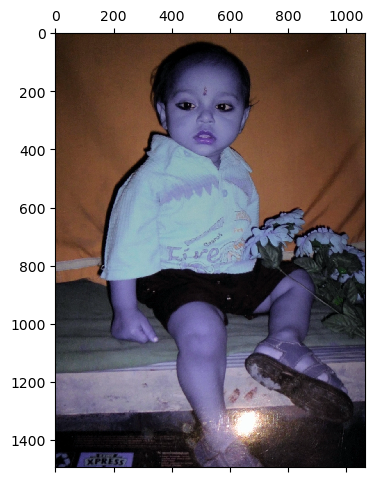

In [18]:
plt.matshow(image)   # Image ko matrix (pixel grid) ke form me display karta hai.
                     # OpenCV image BGR format me hoti hai, isliye colors galat dikh sakte hain.

(np.float64(-0.5), np.float64(1065.5), np.float64(1492.5), np.float64(-0.5))

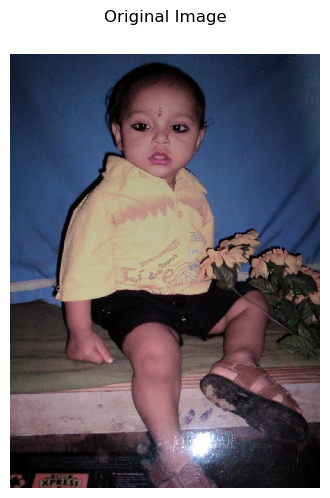

In [20]:
# cv2.cvtColor() image ke color format ko convert karta hai
# Yahan BGR (OpenCV default) ko RGB (Matplotlib format) me convert kar rahe hain
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# plt.matshow() image ko matrix/pixel grid ke form me display karta hai
plt.matshow(rgb_image)

# plt.title() displayed image ke upar heading/title add karta hai
plt.title("Original Image")

# plt.axis() plot ke axes (X-axis aur Y-axis) ko control karta hai.
# 'off' dene se axes, numbers aur border hide ho jaate hain,
# sirf image hi display hoti hai.
plt.axis('off')

(np.float64(-0.5), np.float64(1065.5), np.float64(1492.5), np.float64(-0.5))

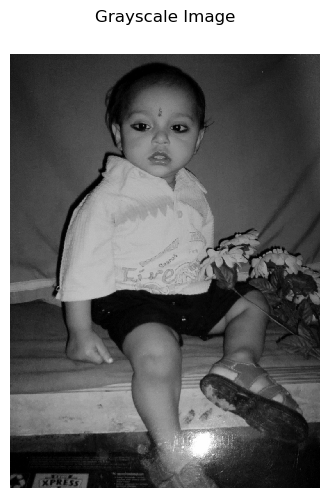

In [22]:
# cv2.cvtColor() image ke color format ko convert karta hai.
# Yahan RGB image ko Grayscale (Black & White shades) me convert kar rahe hain.
# Grayscale image me sirf 1 channel hota hai.
# Har pixel ki value 0 se 255 ke beech hoti hai.

# 0   -> Pure Black (bilkul kala)
# 255 -> Pure White (bilkul safed)
# 1-254 -> Black aur White ke beech ki alag-alag Gray shades
# Value jitni kam hogi image utni dark dikhegi,
# aur jitni zyada hogi utni bright dikhegi.

gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

# Grayscale image ko display kar rahe hain.
plt.matshow(gray_image, cmap='gray')

# Image ke upar title add kar rahe hain.
plt.title("Grayscale Image")

# Axes aur numbers hide kar rahe hain taaki sirf image dikhe.
plt.axis('off')

(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

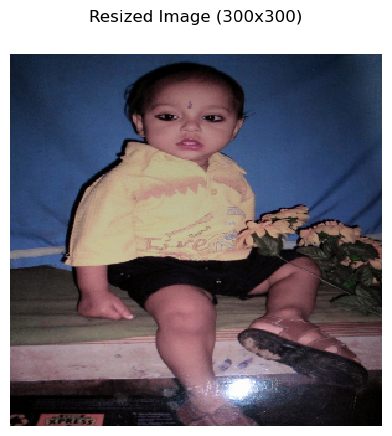

In [23]:
# cv2.resize() image ka size (Width, Height) change karta hai.
# Yahan image ko 300 × 300 pixels me resize kar rahe hain.
resized_image = cv2.resize(rgb_image, (300, 300))

# Resized image ko display kar rahe hain.
plt.matshow(resized_image)

# Image ke upar title add kar rahe hain.
plt.title("Resized Image (300x300)")

# Axes aur numbers hide kar rahe hain.
plt.axis('off')

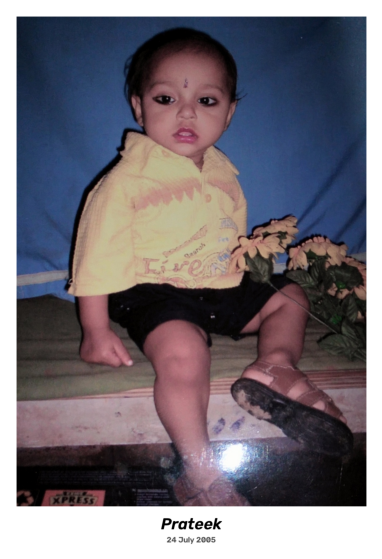

In [32]:
# White border add karke Polaroid frame bana rahe hain
polaroid = cv2.copyMakeBorder(
    rgb_image,
    top=20,
    bottom=130,            # Neeche extra space text ke liye
    left=20,
    right=20,
    borderType=cv2.BORDER_CONSTANT,
    value=[255, 255, 255]  # White border
)

# Polaroid image ki height aur width nikal rahe hain
h, w = polaroid.shape[:2]

# ------------------ Name ------------------

# Jo naam Polaroid ke neeche likhna hai
name = "Prateek"

# Font style, size aur thickness set kar rahe hain
font = cv2.FONT_HERSHEY_SCRIPT_COMPLEX
font_scale = 1.8
thickness = 3

# Text ki width aur height nikal rahe hain taaki center me rakh saken
(text_w, text_h), _ = cv2.getTextSize(name, font, font_scale, thickness)

# Name ko horizontally center kar rahe hain
x = (w - text_w) // 2
y = h - 60

# Name ko Polaroid frame par draw kar rahe hain
cv2.putText(
    polaroid,
    name,
    (x, y),
    font,
    font_scale,
    (0, 0, 0),      # Black color
    thickness,
    cv2.LINE_AA      # Smooth text edges
)

# ------------------ DOB ------------------

# Date of Birth
dob = "24 July 2005"

# DOB ke liye font style aur size
font2 = cv2.FONT_HERSHEY_SIMPLEX
font_scale2 = 0.8
thickness2 = 2

# DOB ki width aur height nikal rahe hain
(text_w2, text_h2), _ = cv2.getTextSize(dob, font2, font_scale2, thickness2)

# DOB ko bhi center align kar rahe hain
x2 = (w - text_w2) // 2
y2 = h - 20

# DOB ko Name ke neeche draw kar rahe hain
cv2.putText(
    polaroid,
    dob,
    (x2, y2),
    font2,
    font_scale2,
    (80, 80, 80),   # Dark Gray color
    thickness2,
    cv2.LINE_AA
)

# Final Polaroid image display kar rahe hain
plt.figure(figsize=(6, 7))
plt.imshow(polaroid)
plt.axis("off")      # Axes hide kar rahe hain
plt.show()

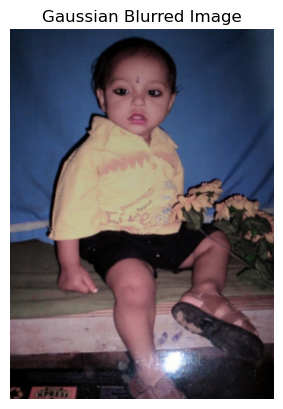

In [31]:
# Gaussian Blur image ke sharp edges aur noise ko smooth karta hai.
# Blur jitna zyada hoga, image utni hi soft dikhegi.

blurred_image = cv2.GaussianBlur(
    rgb_image,      # Input image
    (9, 9),         # Kernel size (Width, Height) - hamesha odd numbers hone chahiye
    0               # Sigma value (0 dene par OpenCV automatically calculate karta hai)
)

# Blurred image display kar rahe hain
plt.imshow(blurred_image)
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

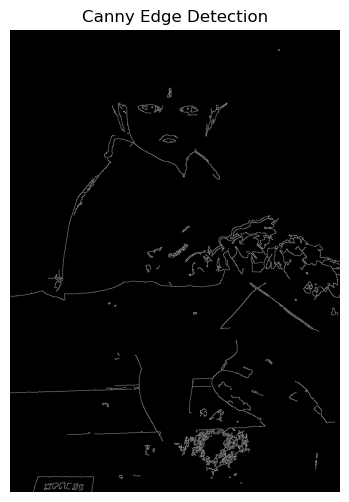

In [35]:
# Canny Edge Detection image ke important edges (boundaries) detect karta hai.
# Edge matlab jahan pixel intensity (brightness) me achanak change hota hai.
# Iska use object detection, shape detection aur image processing me hota hai.

# Grayscale image par Canny Edge Detection apply kar rahe hain
edges = cv2.Canny(
    gray_image,   # Input image (Grayscale image honi chahiye)
    50,          # Lower Threshold: Is value se kam edge ko ignore karta hai
    200           # Upper Threshold: Is value se upar wali edge ko strong edge maanta hai
)

# Edge detected image display kar rahe hain
plt.figure(figsize=(6,6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

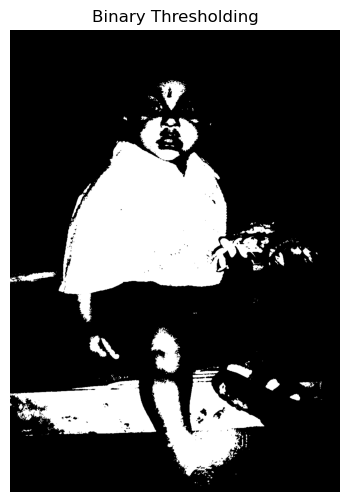

In [41]:
# Thresholding image ko Grayscale se Binary (Black & White) image me convert karta hai.
# Ye har pixel ki intensity ko ek fixed Threshold Value se compare karta hai.
# Iska use image segmentation, text extraction, document scanning aur object detection me hota hai.

# Binary Thresholding apply kar rahe hain
ret, threshold_image = cv2.threshold(
    gray_image,            # Input Grayscale Image
    127,                   # Threshold Value
    255,                   # Maximum Pixel Value (White)
    cv2.THRESH_BINARY      # Binary Thresholding Method
)

# Thresholded image display kar rahe hain
plt.figure(figsize=(6,6))
plt.imshow(threshold_image, cmap="gray")
plt.title("Binary Thresholding")
plt.axis("off")
plt.show()

In [42]:
# cv2.imwrite() image ko computer me save karta hai.
# Pehla parameter file ka naam/path hota hai,
# aur dusra parameter image object hota hai.

cv2.imwrite("saved_image.jpg", image)              # Original image save karega

cv2.imwrite("rgb_image.jpg", rgb_image)            # RGB image save karega

cv2.imwrite("gray_image.jpg", gray_image)          # Grayscale image save karega

cv2.imwrite("blurred_image.jpg", blurred_image)    # Gaussian Blurred image save karega

cv2.imwrite("edges.jpg", edges)                    # Canny Edge image save karega

cv2.imwrite("threshold.jpg", threshold_image)      # Threshold image save karega

cv2.imwrite("polaroid.jpg", polaroid)              # Polaroid image save karega

True